1. selenium으로 아래의 링크에 접속
https://play.google.com/store/apps/details?id=viva.republica.toss
2. 전체리뷰보기를 찾아 클릭
3. 리뷰창이 뜨면 최신순으로 정렬
4. 마우스 스크롤을 해서 오늘부터 2년전 날짜가 나올 때까지 스크롤
5. 데이터 수집
6. csv파일로 저장 -> DB저장
7. 수집 코드를 함수화 KB, 신한, 하나 리뷰도 저장
(링크 주소만 바꾸만 된다)

In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from datetime import datetime, timedelta
import pandas as pd
import time

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")


driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )

url = "https://play.google.com/store/apps/details?id=viva.republica.toss"
driver.get(url)

In [2]:
driver.execute_script(f"window.scrollTo({0}, {1400})")
time.sleep(2)

In [3]:
# 평점 및 리뷰 옆의 -> 버튼 클릭
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "button[aria-label*='평점 및 리뷰 자세히 알아보기']")))
button.click()

In [ ]:
# 리뷰 더 보기 링크 클릭
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "#ow14 > section > div > div.Jwxk6d > div:nth-child(5) > div > div > button")))
button.click()

In [4]:
# 최신순으로 리뷰를 정렬하기 위해서 버튼 클릭
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "#sortBy_1")))
button.click()

In [5]:
# 최신을 찾아 클릭
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "span[aria-label*='최신']")))
button.click()

In [41]:
# 리뷰가 담긴 창을 찾아서 JavaScript로 1000px씩 아래로 스크롤
driver.execute_script("document.querySelector('.fysCi.Vk3ZVd').scrollBy(0, 1000)")

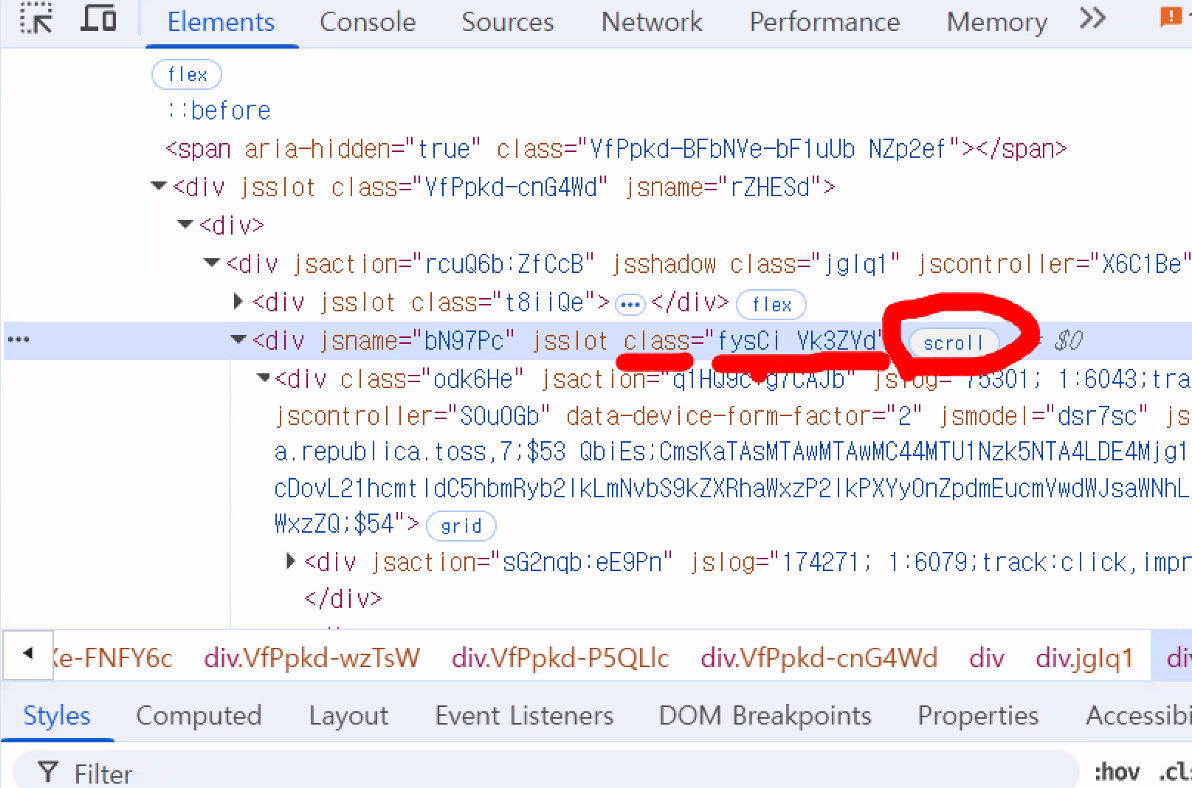

In [6]:
# 별점
driver.find_element(By.CSS_SELECTOR, "div.Jx4nYe > div").get_attribute("aria-label").split()[3][0]

'1'

In [7]:
# 리뷰일
review_date = driver.find_element(By.CSS_SELECTOR, "div.Jx4nYe > span.bp9Aid").get_attribute("innerHTML")

In [8]:
# 사용자리뷰
driver.find_element(By.CSS_SELECTOR, "div.h3YV2d").text

'첫화면 계좌 설정을 왜 시스템이 설정하게 하나요... 제가 원하는 대로 설정 다 해놨는데 멋대로 고정시켜놔서 확인만 더 불편해졌습니다. 정말 이용자가 사용하기 쉽게 업데이트 한게 맞나요?? 이렇게 아무런 통지도 없이 갑작스럽게 시스템 변경하고 잔액 확인하는게 너무 불편해져서 화나네요. 자율성이 떨어져서 이용성이 매우 떨어집니다. 사용하기 쉬운걸로 유명한 토스니까 이 문제도 곧바로 해결해 주실거라 믿습니다. 다시 사용자가 원하는대로 홈화면 설정할 수 있도록 변경해주세요. 계속 이 상태가 계속되면 어쩔 수 없이 토스 계좌를 없애는 것이 방법이 될 수밖에 없네요. 토스의 장점이 없어졌습니다.'

In [9]:
reply = driver.find_element(By.CSS_SELECTOR, "div.ocpBU div.ras4vb > div").get_attribute('innerHTML')
reply

'안녕하세요. 수징 님, 토스팀입니다. 토스를 이용하시면서 느끼신 소중한 의견을 주셔서 감사합니다. 반영될 수 있다 확답 드리기는 어려우나, 고객님께서 말씀해주신 내용은 팀내에 공유하여 보다 편리한 토스 사용 경험을 하실 수 있도록 노력 하겠습니다. 다른 문의 사항이 있다면 24시간 운영되는 카카오톡(@toss) 또는 고객센터 1599-4905로 문의 부탁드립니다. 감사합니다.'

In [10]:
# 오늘로부터 2년전 리뷰까지 수집
# 리뷰일
review_date = driver.find_element(By.CSS_SELECTOR, "div.Jx4nYe > span.bp9Aid").get_attribute("innerHTML")

In [65]:
from datetime import datetime

In [12]:
# 리뷰일을 날짜형 데이터로 변경
# datetime.striptime(yyyy-mm-dd, "%y-%m-%d") 날짜형 데이터 타입으로 변환
review_date = review_date.replace("년 ", "-").replace("월 ", "-").replace("일", "")
review_date = datetime.strptime(review_date, "%Y-%m-%d")

In [13]:
review_date

datetime.datetime(2025, 4, 11, 0, 0)

In [14]:
# 오늘로부터 1달전 데이터 꺼내기
today = datetime.today()
twoyrago = today - timedelta(days=30)

In [11]:
review = driver.find_element(By.CSS_SELECTOR, "div.h3YV2d").text
end_date = driver.find_element(By.CSS_SELECTOR, "div.Jx4nYe > span.bp9Aid").get_attribute("innerHTML")
end_date = end_date.replace("년 ", "-").replace("월 ", "-").replace("일", "")
end_date = datetime.strptime(end_date, "%Y-%m-%d")
end_date

datetime.datetime(2025, 4, 11, 0, 0)

In [ ]:
twoyragoe = today - timedelta(days=30)

In [15]:
print(end_date, twoyrago)
end_date < twoyrago

2025-04-11 00:00:00 2025-03-15 10:17:51.296268


False

In [24]:
review = driver.find_elements(By.CSS_SELECTOR, ".RHo1pe")

In [25]:
len(review)

20

# 1달치 리뷰 모아보기

In [8]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from datetime import datetime, timedelta
import pandas as pd
import time

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")


driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )

url = "https://play.google.com/store/apps/details?id=viva.republica.toss"
driver.get(url)

# 평점 및 리뷰 옆의 -> 버튼 클릭
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "button[aria-label*='평점 및 리뷰 자세히 알아보기']")))
button.click()

# 최신순으로 리뷰를 정렬하기 위해서 버튼 클릭
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "#sortBy_1")))
button.click()

time.sleep(1)

# 최신을 찾아 클릭
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "span[aria-label*='최신']")))
button.click()

# 오늘로부터 1달 전 날짜 만들기
today = datetime.today()
end_date = today - timedelta(days=30)
current_date = ""
reviews = ""

while True:
    
    try:
        # 리뷰가 담긴 창을 찾아서 JavaScript로 1000px씩 아래로 스크롤
        driver.execute_script("document.querySelector('.fysCi.Vk3ZVd').scrollBy(0, 1000)")
        time.sleep(1)
        
        # 리뷰들 중 가장 마지막 데이터의 날짜 추출해 날짜 데이터로 변환
        reviews = driver.find_elements(By.CSS_SELECTOR, ".RHo1pe")
        current_date = reviews[-1].find_element(By.CSS_SELECTOR, "div.Jx4nYe > span.bp9Aid").get_attribute("innerHTML")
        current_date = current_date.replace("년 ", "-").replace("월 ", "-").replace("일", "")
        current_date = datetime.strptime(current_date, "%Y-%m-%d")
        print(f"현재 리뷰 날짜: {current_date}, 리뷰수: {len(reviews)} ", end="\r")
    except:
        reviews = driver.find_elements(By.CSS_SELECTOR, ".RHo1pe")
        print(f"현재 리뷰 날짜: {current_date}, 리뷰수: {len(reviews)} ", end="\r")
        
    if current_date < end_date:
        break  

In [11]:
print(len(reviews))

440


In [17]:
from tqdm import tqdm

all_result = []
for review in tqdm(reviews): 
    # 리뷰일
    review_date=driver.find_element(By.CSS_SELECTOR, "div.Jx4nYe > span.bp9Aid").get_attribute("innerHTML")
    # 리뷰일을 날짜형 데이터로 변경
    # datetime.striptime(yyyy-mm-dd, "%y-%m-%d") 날짜형 데이터 타입으로 변환
    review_date = review_date.replace("년 ", "-").replace("월 ", "-").replace("일", "")
    review_date = datetime.strptime(review_date, "%Y-%m-%d")
    # 별점
    rating = review.find_element(By.CSS_SELECTOR, "div.Jx4nYe > div").get_attribute("aria-label").split()[3][0]
    # 사용자리뷰
    user_review  = review.find_element(By.CSS_SELECTOR, "div.h3YV2d").text
    
    try:
        # 업체 댓글
        reply = review.find_element(By.CSS_SELECTOR, "div.ocpBU div.ras4vb > div").get_attribute('innerHTML')
    except:
        reply = None
        
    result = (review_date, rating, user_review, reply)
    all_result.append(result)
result_df = pd.DataFrame(all_result, columns=['리뷰일', '평점', '사용자리뷰', '업체답변'])
result_df

100%|████████████████████████████████████████████████████████████████████████████████| 440/440 [00:16<00:00, 27.28it/s]


,리뷰일,평점,사용자리뷰,업체답변
0,2025-04-11,4,이제 됐네요,"안녕하세요. 임의수님, 토스팀입니다. 불편한 사항이 잘 해소 되셨을까요? 보다 편리..."
1,2025-04-11,4,토스의 장점이 사용하기 편하다는 거였는데 업데이트되면서 갑자기 홈화면이 자동으로 간...,"안녕하세요. 은정 님, 토스팀입니다. 토스를 이용하시면서 느끼신 소중한 의견을 주셔..."
2,2025-04-11,4,잔액가리기가 적용이 안됩니다! 금액가리기가 안된다구요. 개발자면은 항목은 알고 있어...,"안녕하세요. 박남규님, 토스팀입니다. 홈 화면 잔액 숨기기의 경우 아래 경로로 진행..."
3,2025-04-11,5,좋아요.,None
4,2025-04-11,3,토스뱅크 내역 스크롤이 잘 안되네요 자꾸 보다 멈추네요 업데이트 해도,"안녕하세요, 고객님. 토스뱅크 고객센터입니다. 고객님 토스뱅크 이용중 불편을 드린 ..."
...,...,...,...,...
435,2025-04-11,1,맘대로 뭐가 변경되어있고 주식보여주는 것도 맘대로 보여주는거 처럼 뭐가 안 맞음,"안녕하세요. 최명식님, 토스팀입니다. 우선, 토스 이용에 불편을 드려 죄송합니다. ..."
436,2025-04-11,3,오늘의 행운복권 들어가면 cannot read properties of undefi...,"안녕하세요. Randoo님, 토스팀입니다. 우선, 토스 이용에 불편을 드려 죄송합니..."
437,2025-04-11,1,미친광고,"안녕하세요. 고객님, 토스팀입니다. 먼저 서비스 이용에 불편을 드렸다면 대단히 죄송..."
438,2025-04-11,5,사용편함,None


# 하나로 합치기

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from datetime import datetime, timedelta
import pandas as pd
import time
from tqdm import tqdm

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")


driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )

url = "https://play.google.com/store/apps/details?id=viva.republica.toss"
driver.get(url)

# 평점 및 리뷰 옆의 -> 버튼 클릭
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "button[aria-label*='평점 및 리뷰 자세히 알아보기']")))
button.click()

# 최신순으로 리뷰를 정렬하기 위해서 버튼 클릭
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "#sortBy_1")))
button.click()

time.sleep(3)

# 최신을 찾아 클릭
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "span[aria-label*='최신']")))
button.click()

# 오늘로부터 1달 전 날짜 만들기
today = datetime.today()
end_date = today - timedelta(days=30)
current_date = ""
reviews = ""

while True:
    
    try:
        # 리뷰가 담긴 창을 찾아서 JavaScript로 1000px씩 아래로 스크롤
        driver.execute_script("document.querySelector('.fysCi.Vk3ZVd').scrollBy(0, 1000)")
        time.sleep(1)
        
        # 리뷰들 중 가장 마지막 데이터의 날짜 추출해 날짜 데이터로 변환
        reviews = driver.find_elements(By.CSS_SELECTOR, ".RHo1pe")
        current_date = reviews[-1].find_element(By.CSS_SELECTOR, "div.Jx4nYe > span.bp9Aid").get_attribute("innerHTML")
        current_date = current_date.replace("년 ", "-").replace("월 ", "-").replace("일", "")
        current_date = datetime.strptime(current_date, "%Y-%m-%d")
        print(f"현재 리뷰 날짜: {current_date}, 리뷰수: {len(reviews)} ", end="\r")
    except:
        reviews = driver.find_elements(By.CSS_SELECTOR, ".RHo1pe")
        print(f"현재 리뷰 날짜: {current_date}, 리뷰수: {len(reviews)} ", end="\r")
        
    if current_date < end_date:
        break  

#########################################################################################
# 리뷰 추출 부분

all_result = []
for review in tqdm(reviews): 
    # 리뷰일
    review_date=driver.find_element(By.CSS_SELECTOR, "div.Jx4nYe > span.bp9Aid").get_attribute("innerHTML")
    # 리뷰일을 날짜형 데이터로 변경
    # datetime.striptime(yyyy-mm-dd, "%y-%m-%d") 날짜형 데이터 타입으로 변환
    review_date = review_date.replace("년 ", "-").replace("월 ", "-").replace("일", "")
    review_date = datetime.strptime(review_date, "%Y-%m-%d")
    # 별점
    rating = review.find_element(By.CSS_SELECTOR, "div.Jx4nYe > div").get_attribute("aria-label").split()[3][0]
    # 사용자리뷰
    user_review  = review.find_element(By.CSS_SELECTOR, "div.h3YV2d").text
    
    try:
        # 업체 댓글
        reply = review.find_element(By.CSS_SELECTOR, "div.ocpBU div.ras4vb > div").get_attribute('innerHTML')
    except:
        reply = None
        
    result = (review_date, rating, user_review, reply)
    all_result.append(result)
result_df = pd.DataFrame(all_result, columns=['리뷰일', '평점', '사용자리뷰', '업체답변'])
result_df.to_csv("./scraping_results/viva_republica_toss_review_result.csv", index=False, encoding=oding = "utf-8-sig")

In [20]:
result_df.to_csv("./scraping_results/viva_republica_toss_review_result.csv", index=False, encoding = "utf-8-sig")

# 여러 은행 앱의 리뷰 데이터 수집하기

In [26]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from datetime import datetime, timedelta
import pandas as pd
import time
from tqdm import tqdm

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")


driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )

bank_app_list = ["viva.republica.toss", "com.shinhan.sbanking", "com.kbstar.kbbank", 
                 "com.kebhana.hanapush", "com.wooribank.smart.npib", "com.rainist.banksalad2"]

for bank in bank_app_list:
    
    
    url = f"https://play.google.com/store/apps/details?id={bank}"
    driver.get(url)

    # 평점 및 리뷰 옆의 -> 버튼 클릭
    wait = WebDriverWait(driver, 10)
    button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "button[aria-label*='평점 및 리뷰 자세히 알아보기']")))
    button.click()

    # 최신순으로 리뷰를 정렬하기 위해서 버튼 클릭
    wait = WebDriverWait(driver, 10)
    button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "#sortBy_1")))
    button.click()

    time.sleep(3)

    # 최신을 찾아 클릭
    wait = WebDriverWait(driver, 10)
    button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "span[aria-label*='최신']")))
    button.click()

    # 오늘로부터 1달 전 날짜 만들기
    today = datetime.today()
    end_date = today - timedelta(days=30)
    current_date = ""
    reviews = ""

    while True:

        try:
            # 리뷰가 담긴 창을 찾아서 JavaScript로 1000px씩 아래로 스크롤
            driver.execute_script("document.querySelector('.fysCi.Vk3ZVd').scrollBy(0, 1000)")
            time.sleep(1)

            # 리뷰들 중 가장 마지막 데이터의 날짜 추출해 날짜 데이터로 변환
            reviews = driver.find_elements(By.CSS_SELECTOR, ".RHo1pe")
            current_date = reviews[-1].find_element(By.CSS_SELECTOR, "div.Jx4nYe > span.bp9Aid").get_attribute("innerHTML")
            current_date = current_date.replace("년 ", "-").replace("월 ", "-").replace("일", "")
            current_date = datetime.strptime(current_date, "%Y-%m-%d")
            print(f"{bank} 현재 리뷰 날짜: {current_date}, 리뷰수: {len(reviews)} ", end="\r")
        except:
            reviews = driver.find_elements(By.CSS_SELECTOR, ".RHo1pe")
            print(f"{bank} 현재 리뷰 날짜: {current_date}, 리뷰수: {len(reviews)} ", end="\r")

        if current_date < end_date:
            break      
    
    #########################################################################################
    # 리뷰 추출 부분

    all_result = []
    for review in tqdm(reviews): 
        # 리뷰일
        review_date=driver.find_element(By.CSS_SELECTOR, "div.Jx4nYe > span.bp9Aid").get_attribute("innerHTML")
        # 리뷰일을 날짜형 데이터로 변경
        # datetime.striptime(yyyy-mm-dd, "%y-%m-%d") 날짜형 데이터 타입으로 변환
        review_date = review_date.replace("년 ", "-").replace("월 ", "-").replace("일", "")
        review_date = datetime.strptime(review_date, "%Y-%m-%d")
        # 별점
        rating = review.find_element(By.CSS_SELECTOR, "div.Jx4nYe > div").get_attribute("aria-label").split()[3][0]
        # 사용자리뷰
        user_review  = review.find_element(By.CSS_SELECTOR, "div.h3YV2d").text

        try:
            # 업체 댓글
            reply = review.find_element(By.CSS_SELECTOR, "div.ocpBU div.ras4vb > div").get_attribute('innerHTML')
        except:
            reply = None

        result = (review_date, rating, user_review, reply)
        all_result.append(result)
    result_df = pd.DataFrame(all_result, columns=['리뷰일', '평점', '사용자리뷰', '업체답변'])
    result_df.to_csv(f"./scraping_results/{bank}_review_result.csv", index=False, encoding = "utf-8-sig")
driver.close()

100%|████████████████████████████████████████████████████████████████████████████████| 440/440 [00:13<00:00, 33.09it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:03<00:00, 32.63it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 800/800 [00:24<00:00, 33.05it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:02<00:00, 34.34it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 160/160 [00:04<00:00, 33.52it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:01<00:00, 31.08it/s]


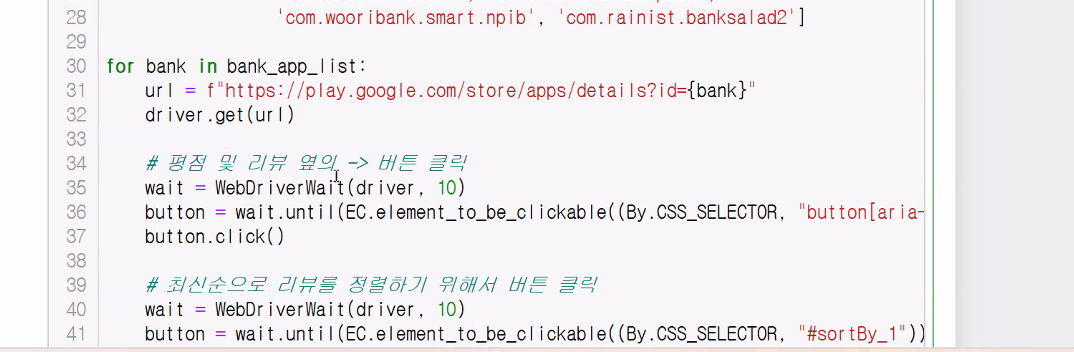

# 여러 은행 앱의 리뷰 데이터 수집하기 함수화

In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from datetime import datetime, timedelta
import pandas as pd
import time
from tqdm import tqdm
from bankdbio import to_bank_db

In [19]:
def bank_app_reviews(bank, month=1):
    options = Options()
    options.add_experimental_option("detach", True)
    options.add_argument("start-maximized")
    options.add_argument("Chrome/135.0.0.0")
    options.add_argument("lang=ko_KR")
    # 웹브라우저가 백그라운드에서 작동하도록 설정
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usaeg")

    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
        )

    url = f"https://play.google.com/store/apps/details?id={bank}"
    driver.get(url)

    # 평점 및 리뷰 옆의 -> 버튼 클릭
    wait = WebDriverWait(driver, 10)
    button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "button[aria-label*='평점 및 리뷰 자세히 알아보기']")))
    button.click()

    # 최신순으로 리뷰를 정렬하기 위해서 버튼 클릭
    wait = WebDriverWait(driver, 10)
    button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "#sortBy_1")))
    button.click()
    
    time.sleep(1)

    # 최신을 찾아 클릭
    wait = WebDriverWait(driver, 10)
    button = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "span[aria-label*='최신']")))
    button.click()

    time.sleep(3)

    # 오늘로부터 1달 전 날짜 만들기
    today = datetime.today()
    end_date = today - timedelta(days=year * 365)
    current_date = ""
    reviews = ""

    while True:

        try:
            # 리뷰가 담긴 창을 찾아서 JavaScript로 1000px씩 아래로 스크롤
            driver.execute_script("document.querySelector('.fysCi.Vk3ZVd').scrollBy(0, 1000)")
            time.sleep(1)

            # 리뷰들 중 가장 마지막 데이터의 날짜 추출해 날짜 데이터로 변환
            reviews = driver.find_elements(By.CSS_SELECTOR, ".RHo1pe")
            current_date = reviews[-1].find_element(By.CSS_SELECTOR, "div.Jx4nYe > span.bp9Aid").get_attribute("innerHTML")
            current_date = current_date.replace("년 ", "-").replace("월 ", "-").replace("일", "")
            current_date = datetime.strptime(current_date, "%Y-%m-%d")
            print(f"{bank} 현재 리뷰 날짜: {current_date}, 리뷰수: {len(reviews)} ", end="\r")
        except:
            reviews = driver.find_elements(By.CSS_SELECTOR, ".RHo1pe")
            print(f"{bank} 현재 리뷰 날짜: {current_date}, 리뷰수: {len(reviews)} ", end="\r")

        if current_date < end_date:
            break      
    return driver, reviews

In [20]:
def review_extraction(driver, reviews):
    all_result = []
    for review in tqdm(reviews): 
        # 리뷰일
        review_date=driver.find_element(By.CSS_SELECTOR, "div.Jx4nYe > span.bp9Aid").get_attribute("innerHTML")
        # 리뷰일을 날짜형 데이터로 변경
        # datetime.striptime(yyyy-mm-dd, "%y-%m-%d") 날짜형 데이터 타입으로 변환
        review_date = review_date.replace("년 ", "-").replace("월 ", "-").replace("일", "")
        review_date = datetime.strptime(review_date, "%Y-%m-%d")
        # 별점
        rating = review.find_element(By.CSS_SELECTOR, "div.Jx4nYe > div").get_attribute("aria-label").split()[3][0]
        # 사용자리뷰
        user_review  = review.find_element(By.CSS_SELECTOR, "div.h3YV2d").text

        try:
            # 업체 댓글
            reply = review.find_element(By.CSS_SELECTOR, "div.ocpBU div.ras4vb > div").get_attribute('innerHTML')
        except:
            reply = None

        result = (review_date, rating, user_review, reply)
        all_result.append(result)
    result_df = pd.DataFrame(all_result, columns=['리뷰일', '평점', '사용자리뷰', '업체답변'])
#     result_df.to_csv(f"./scraping_results/{bank}_review_result.csv", index=False, encoding = "utf-8-sig")
    to_bank_db(bank, result_df)
    print(f"{bank} 리뷰 저장 완료")
    driver.close()

In [22]:
bank_app_list = ["viva.republica.toss", "com.shinhan.sbanking", "com.kbstar.kbbank", 
                 "com.kebhana.hanapush", "com.wooribank.smart.npib", "com.rainist.banksalad2"]

for bank in bank_app_list:
    driver, reviews = bank_app_reviews(bank, 2)
    review_extraction(driver, reviews)

100%|████████████████████████████████████████████████████████████████████████████████| 880/880 [00:28<00:00, 31.10it/s]


viva.republica.toss 리뷰 저장 완료


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:06<00:00, 31.27it/s]


com.shinhan.sbanking 리뷰 저장 완료


100%|██████████████████████████████████████████████████████████████████████████████| 1480/1480 [01:05<00:00, 22.65it/s]


...

com.kebhana.hanapush 리뷰 저장 완료


100%|████████████████████████████████████████████████████████████████████████████████| 420/420 [00:19<00:00, 21.04it/s]


com.wooribank.smart.npib 리뷰 저장 완료


100%|██████████████████████████████████████████████████████████████████████████████████| 60/60 [00:02<00:00, 21.03it/s]


com.rainist.banksalad2 리뷰 저장 완료


# google play scraper 라이브러리

In [25]:
pip install google-play-scraper

Note: you may need to restart the kernel to use updated packages.


In [26]:
from google_play_scraper import app

result = app(
    'viva.republica.toss',
    lang='ko', # defaults to 'en'
    country='kr' # defaults to 'us'
)

In [19]:
# 리뷰일
driver.find_element(By.CSS_SELECTOR, "div.Jx4nYe > span").text

'2025년 4월 11일'

In [27]:
result

{'title': '토스',
 'description': "<b>토스뱅크, 토스증권 서비스를 이용하시려면 토스 앱 설치가 필요합니다.</b>\r\n\r\n● 내 금융 현황을 한눈에, 홈·소비\r\n· 모든 계좌의 모든 정보를 한 곳에서, 따로 보았던 예적금, 청약, 증권, 대출 계좌의 정보를 한 곳에서 확인할 수 있어요.\r\n· 얼마나 벌고 얼마나 썼을까? 한 달 동안의 수입과 소비를 시간순으로 모아볼 수 있고, 소비 분석 리포트도 제공해 드려요.\r\n· 카드 실적 헷갈릴 필요 없이, 실적을 충족한 카드가 무엇인지 얼마나 더 써야 실적을 달성하는지 한눈에 확인할 수 있어요.\r\n· 매달 고정적으로 나가는 보험비, 생활요금, 구독료 등도 쉽게 확인할 수 있어요.\r\n\r\n● 평생 무료로 간편하고 안전하게, 송금\r\n· 송금을 자유롭게, 토스에서는 은행 상관없이 수수료가 평생 무료에요.\r\n· 송금을 안전하게, 송금 전 사기계좌를 미리 조회해 안전하게 송금할 수 있어요.\r\n· 송금을 간편하게, 단 한 번의 터치까지 줄였어요. 최소한의 터치로 송금하세요.\r\n· 그리고 마음까지, 간단한 메시지와 이모티콘을 함께 보내보세요.\r\n\r\n● 지점에 가지 않아도 OK, 개설\r\n· 시간과 장소에 상관없이, 카드, 예·적금, 대출, 보험 등 다양한 금융상품을 개설할 수 있습니다.\r\n· 특별한 혜택은 덤으로, 토스에서만 드리는 혜택 또한 놓치지 마세요.\r\n\r\n● 보험 관리를 한눈에, 보험\r\n· 가입한 보험과 월 보험료를 한눈에 확인하세요.\r\n· 또래에 비해 부족한 것은 없을까? 현재 가입한 보험의 보장을 참고해 부족한 보장을 추천해드립니다.\r\n· 전문가와 상담을 통해 내게 딱 맞는 보험을 추천 받고, 병원비도 간편하게 청구해 돌려받을 수 있어요.\r\n\r\n● 누구나 받을 수 있는, 혜택\r\n· 좋아하는 브랜드를 더 사랑할 수 있도록, 1주일에 한 번씩 브랜드를 고르고 캐시백을 받아보세요.\r\n· 이번 주 미션을 달성하고 포인

In [28]:
from google_play_scraper import Sort, reviews

result, continuation_token = reviews(
    'viva.republica.toss',
    lang='ko', # defaults to 'en'
    country='kr', # defaults to 'us'
    sort=Sort.NEWEST, # defaults to Sort.NEWEST
    # defaults to 100
    # defaults to None(means all score)
)

# If you pass `continuation_token` as an argument to the reviews function at this point,
# it will crawl the items after 3 review items.

result, _ = reviews(
    'viva.republica.toss',
    continuation_token=continuation_token # defaults to None(load from the beginning)
)

In [29]:
result

[{'reviewId': '3cf6cb72-0ccd-4636-bbc7-dd8597835636',
  'userName': 'Lun tera',
  'userImage': 'https://play-lh.googleusercontent.com/a/ACg8ocKdB8AQ6v4LM8Eru_HO7Ds2Hl-A7turS6vC18n2LJNvAKAxyw=mo',
  'content': '만보기 기능 필요없으니 알림창에 안 뜨게 해주세요. 어플에 투자는 안하면서 광고는 미친듯이 집어넣어서 안 그래도 무거운 어플 더 느려터지고 열불나게 하네요.',
  'score': 1,
  'thumbsUpCount': 4,
  'reviewCreatedVersion': '5.205.0',
  'at': datetime.datetime(2025, 4, 3, 1, 14, 28),
  'replyContent': "안녕하세요. Lun tera 님, 토스팀입니다. 이용에 불편을 드린 것 같아 마음이 무겁습니다. 만보기 알림이 보이지 않기를 원하시는 경우 아래의 방법으로 알림을 보이지않게 하실 수 있습니다. 1. 휴대폰 설정 → 알림 → 앱 알림 → 토스 → 상단의 '알림 허용 OFF' 2. 휴대폰 설정 → 알림 → 앱 알림 → 토스 → 하단의 [알림 카테고리] → '만보기 OFF' 다만 알림을 끄게될 경우 만보기 기능이 작동하지 않을 수 있는 점 참고부탁드립니다. 위 방법으로 진행이 어렵거나 다른 문의사항 있으실 경우 24시간 운영되는 카카오톡(@toss) 또는 토스 고객센터 1599-4905로 문의 부탁드립니다. 감사합니다.",
  'repliedAt': datetime.datetime(2025, 4, 3, 7, 8, 49),
  'appVersion': '5.205.0'},
 {'reviewId': 'd82a4c33-f6e3-4cca-8415-d2395c2b2a25',
  'userName': 'noh Mr',
  'userImage': 'https://play-lh.googleusercont